### Import Libraries

In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from torch.utils.data import DataLoader
from src.org_unet_parts import *
from dataloader import ACDCDataset
%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}')

Using device cuda


### Data Loading

In [3]:
batch_size = 16

In [4]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation')
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


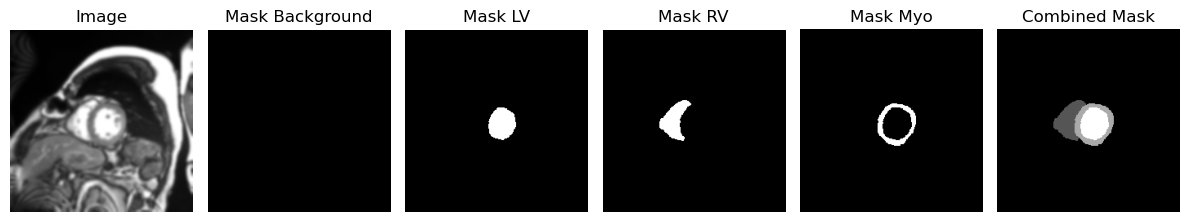

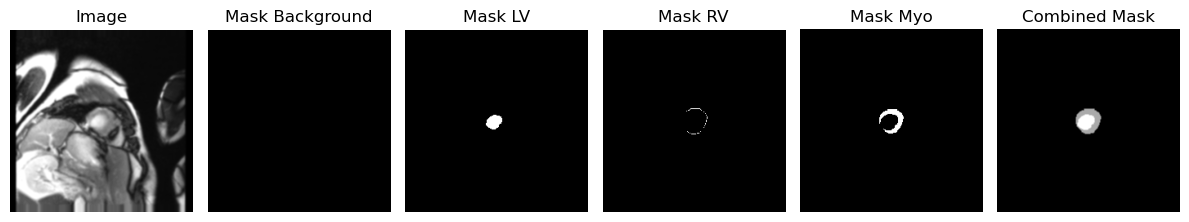

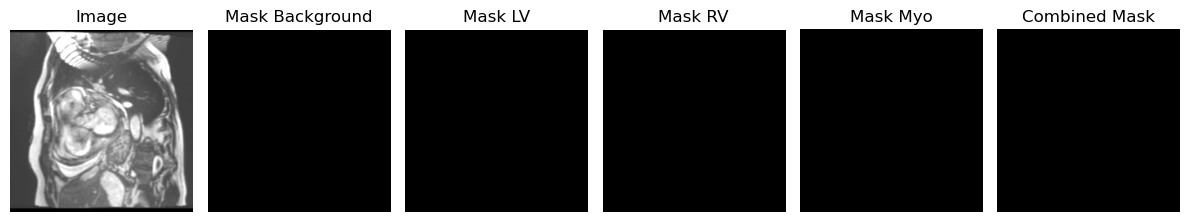

In [5]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 3

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    image = sample['image'][i].squeeze().numpy()  # Convert to numpy array
    msk_all = sample['masks_all'][i].squeeze().numpy()
    masks = sample['masks'][i]
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 6, figsize=(12, 5))

    # Plot the image and masks
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(msk_bkg, cmap='gray')
    axes[1].set_title('Mask Background')
    axes[1].axis('off')

    axes[2].imshow(msk_lv, cmap='gray')
    axes[2].set_title('Mask LV')
    axes[2].axis('off')

    axes[3].imshow(msk_rv, cmap='gray')
    axes[3].set_title('Mask RV')
    axes[3].axis('off')

    axes[4].imshow(msk_myo, cmap='gray')
    axes[4].set_title('Mask Myo')
    axes[4].axis('off')

    axes[5].imshow(msk_all, cmap='gray')
    axes[5].set_title('Combined Mask')
    axes[5].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

In [6]:
# # Get the next batch from the DataLoader
# data_iterator = iter(train_dataloader)
# sample = next(data_iterator)
# idx = 1
# 
# # Extract data from the sample
# image = sample['image'][idx].squeeze().numpy()  # Convert to numpy array
# msk_all = sample['masks_all'][idx].squeeze().numpy()
# masks = sample['masks'][idx]
# msk_bkg = sample['masks'][idx][0].squeeze().numpy()
# msk_lv = sample['masks'][idx][1].squeeze().numpy()
# msk_rv = sample['masks'][idx][2].squeeze().numpy()
# msk_myo = sample['masks'][idx][3].squeeze().numpy()

### Bounding Box Generation

In [7]:
def get_combined_bounding_box_with_margin(stacked_masks, margin=0.02):
    """
    Compute a single bounding box with a margin that encompasses all non-zero regions across stacked binary masks.
    Args:
        stacked_masks: PyTorch tensor of shape (N, H, W) with binary values (0 or 1),
                       where N is the number of masks.
        margin: Float, margin to add to the bounding box as a fraction of width/height.
    Returns:
        bounding_box: [x_min, y_min, x_max, y_max] in normalized coordinates.
    """
    combined_mask = torch.any(stacked_masks, dim=0).int()  # Combine masks into a single mask
    
    if torch.sum(combined_mask) == 0:
        # Default bounding box when no ROI is present
        return [0.0, 0.0, 1.0, 1.0], combined_mask
    else:
        rows = torch.any(combined_mask, dim=1)
        cols = torch.any(combined_mask, dim=0)
        
        y_min, y_max = torch.where(rows)[0][[0, -1]]
        x_min, x_max = torch.where(cols)[0][[0, -1]]

        # Add margin
        height, width = combined_mask.shape
        y_min = max(0, y_min.item() - int(margin * height))
        y_max = min(height, y_max.item() + int(margin * height))
        x_min = max(0, x_min.item() - int(margin * width))
        x_max = min(width, x_max.item() + int(margin * width))
        
        bounding_box = [x_min, y_min, x_max, y_max]
        return bounding_box, combined_mask

In [8]:
# Generate ground truth bounding boxes from masks
bounding_box, combined_mask = get_combined_bounding_box_with_margin(masks, margin=0.05)  # Add 5% margin

bounding_box

[0.0, 0.0, 1.0, 1.0]

### Visualize Bounding Boxes

In [9]:
def visualize_image_and_mask_with_bounding_box(image, bounding_box, combined_mask):
    """
    Visualize the original image and the combined mask with the bounding box.
    Args:
        image: PyTorch tensor of shape (H, W) or (H, W, C) for the original image.
        bounding_box: [x_min, y_min, x_max, y_max] in pixel coordinates.
        combined_mask: PyTorch tensor of shape (H, W).
    """
    x_min, y_min, x_max, y_max = bounding_box
    
    image = torch.from_numpy(image).float()
    
    # Plot the original image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    if image.dim() == 3:  # If image has color channels
        plt.imshow(image.permute(1, 2, 0).numpy())
    else:
        plt.imshow(image.numpy(), cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Plot the combined mask with bounding box
    plt.subplot(1, 2, 2)
    plt.imshow(combined_mask.numpy(), cmap='gray')
    plt.plot([x_min, x_max], [y_min, y_min], color='red')  # Top edge
    plt.plot([x_min, x_max], [y_max, y_max], color='red')  # Bottom edge
    plt.plot([x_min, x_min], [y_min, y_max], color='red')  # Left edge
    plt.plot([x_max, x_max], [y_min, y_max], color='red')  # Right edge
    plt.title("Combined Mask with Bounding Box")
    plt.axis('off')

    plt.show()
    
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {combined_mask.shape}")
    print(f"Image min: {image.min()}")
    print(f"Image max: {image.max()}")
    print(f"Mask min: {combined_mask.min()}")
    print(f"Mask max: {combined_mask.max()}")

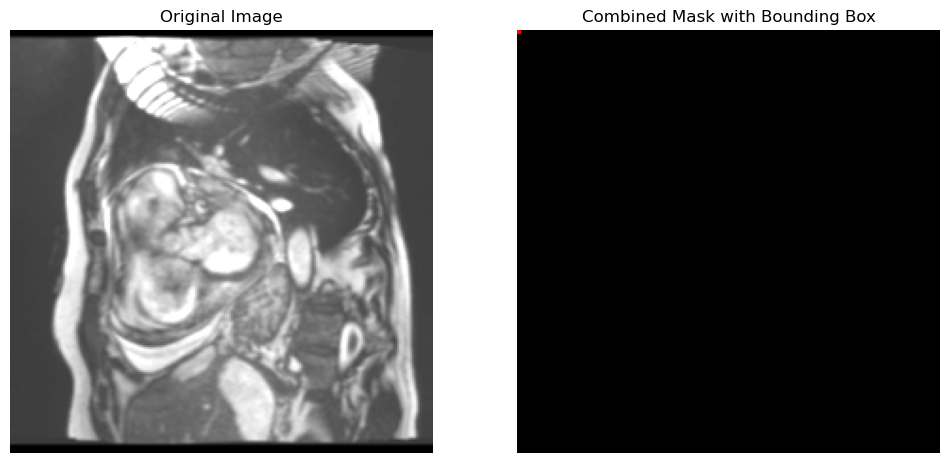

Image shape: torch.Size([224, 224])
Mask shape: torch.Size([224, 224])
Image min: -1.0
Image max: 1.0
Mask min: 0
Mask max: 0


In [10]:
visualize_image_and_mask_with_bounding_box(image, bounding_box, combined_mask)